# TP1: Zoom in / Zoom out of images
## Autor: Volodya ALEKSANYAN

**Goal**: Take an image, look at its 2D spectrum, then resize it two ways in each direction:
- half size: (a) subsampling in space, (b) cropping the spectrum (low-pass) then inverse FFT
- double size: (a) sinc interpolation = zero-padding the spectrum then inverse FFT, (b) linear interpolation in space

image shape: (512, 512) dtype: float64


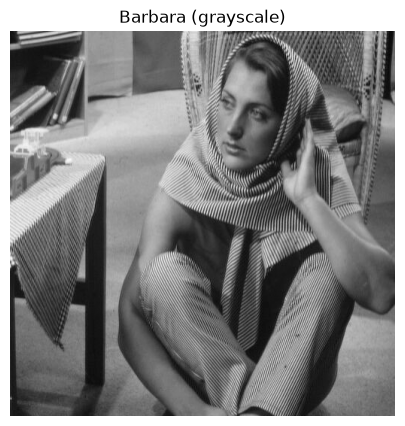

In [37]:
import numpy as np
from PIL import Image
from scipy.ndimage import zoom
import matplotlib.pyplot as plt

img = np.array(Image.open("../data/barbara.jpg").convert("L"), dtype=np.float64)
print("image shape:", img.shape, "dtype:", img.dtype)

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Barbara (grayscale)")
plt.axis("off")
plt.show()

## Spectral analysis

2D FFT, shifted so the DC component sits at the center. We look at the log-magnitude to see where the energy lives.

In [38]:
def fft2c(x):
    return np.fft.fftshift(np.fft.fft2(x))

def ifft2c(X):
    return np.real(np.fft.ifft2(np.fft.ifftshift(X)))

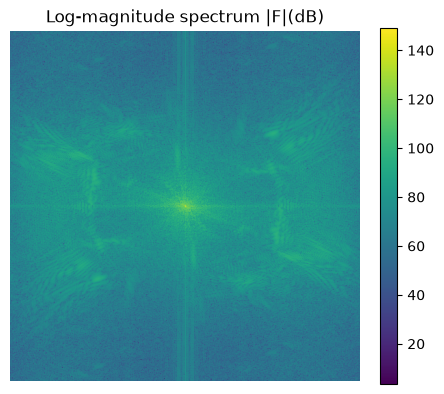

energy ratio : 1.26%


In [40]:
F = fft2c(img)
magnitude_db = 20 * np.log10(np.abs(F) + 1)

plt.figure(figsize=(5, 5))
plt.imshow(magnitude_db, cmap="viridis")
plt.title("Log-magnitude spectrum |F|(dB)")
plt.axis("off")
plt.colorbar(fraction=0.046)
plt.show()

h, w = img.shape
cy, cx = h // 2, w // 2
outer_mask = np.ones((h, w), dtype=bool)
outer_mask[cy - h // 4 : cy + h // 4, cx - w // 4 : cx + w // 4] = False
outer_energy_ratio = np.sum(np.abs(F[outer_mask]) ** 2) / np.sum(np.abs(F) ** 2)
print(f"energy ratio : {outer_energy_ratio:.2%}")

I want to see what happens if we don't shift to the 'center'. Normally, there is no difference at the end, but there is only a visualization difference. So I'll still use fftshift, but there is no difference.

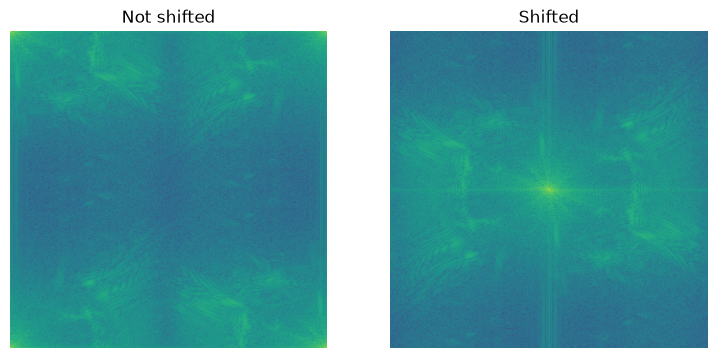

- Same values once shifted ? 
- Yes


In [41]:
F_raw = np.fft.fft2(img)
magnitude_db_raw = 20 * np.log10(np.abs(F_raw) + 1)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(magnitude_db_raw, cmap="viridis")
axes[0].set_title("Not shifted")
axes[1].imshow(magnitude_db, cmap="viridis")
axes[1].set_title("Shifted")
for ax in axes:
    ax.axis("off")
plt.show()

# Literally the same array, just re-ordered
print("- Same values once shifted ?", "\n-", "Yes" if np.array_equal(np.fft.fftshift(magnitude_db_raw), magnitude_db) else "No")

## Half size

Two ways to crop N into N/2:
- We can subsample and keep only every 2 pixel.
- We can also use Fourier to crop the spectrum into N/2xN/2 block then inverse FFT. 

normal and centered, max abs diff: 0.0


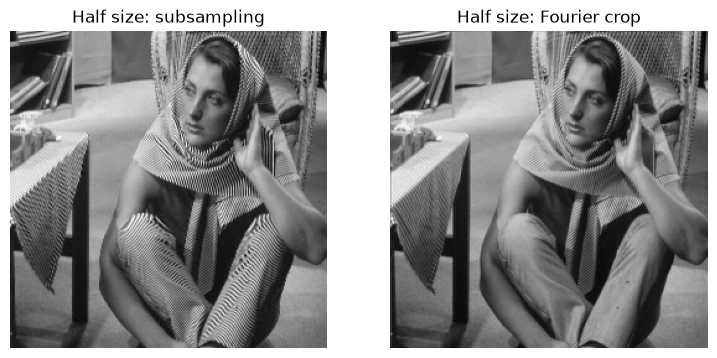

In [42]:
def resize_fourier(x, new_shape):
    """Crop or zero-pad the spectrum on non-shifted axes, then inverse FFT."""
    (oh, ow), (nh, nw) = x.shape, new_shape
    X = np.fft.fft2(x)
    Y = np.zeros(new_shape, dtype=complex)

    def split(old, new):
        # how many low frequencies to keep
        m = min(old, new)
        lo = (m+1) // 2
        return lo, m - lo

    lh, hh = split(oh, nh)
    lw, hw = split(ow, nw)
    Y[:lh, :lw] = X[:lh, :lw]
    Y[:lh, nw - hw : nw] = X[:lh, ow - hw : ow]
    Y[nh - hh : nh, :lw] = X[oh - hh : oh, :lw]
    Y[nh - hh : nh, nw - hw : nw] = X[oh - hh : oh, ow - hw : ow]
    scale = (nh * nw) / (oh * ow)

    return np.real(np.fft.ifft2(Y)) * scale


def resize_fourier_centered(x, new_shape):
    """Same thing but going through the shifted ("centered") spectrum, just for comparison."""
    (oh, ow), (nh, nw) = x.shape, new_shape
    X = fft2c(x)
    Y = np.zeros(new_shape, dtype=complex)
    mh, mw = min(oh, nh), min(ow, nw)
    oy, ox = (oh - mh) // 2, (ow - mw) // 2
    ny, nx = (nh - mh) // 2, (nw - mw) // 2
    Y[ny : ny + mh, nx : nx + mw] = X[oy : oy + mh, ox : ox + mw]
    scale = (nh * nw) / (oh * ow)

    return ifft2c(Y) * scale


half_shape = (h // 2, w // 2)
img_subsampled = img[::2, ::2]
img_fourier_small = resize_fourier(img, half_shape)

print("normal and centered, max abs diff:", np.max(np.abs(img_fourier_small - resize_fourier_centered(img, half_shape))))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img_subsampled, cmap="gray")
axes[0].set_title("Half size: subsampling")
axes[1].imshow(img_fourier_small, cmap="gray")
axes[1].set_title("Half size: Fourier crop")
for ax in axes:
    ax.axis("off")
plt.show()

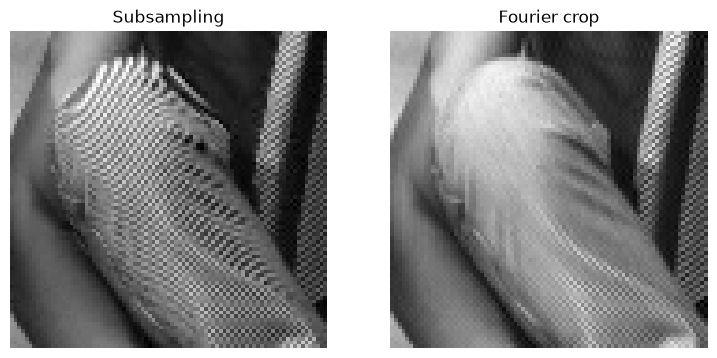

In [44]:
crop_full = np.s_[280:450, 150:320]
crop_half = np.s_[140:225, 75:160]

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(img_subsampled[crop_half], cmap="gray")
axes[0].set_title("Subsampling")
axes[1].imshow(img_fourier_small[crop_half], cmap="gray")
axes[1].set_title("Fourier crop")
for ax in axes:
    ax.axis("off")
plt.show()

**Analysis :** 

Vizually, it is much more smooth to watch the Fourrier cropping. Strips are not very visible, while the subsambing gives a very strong artefacts. 

## Double the size

- Sinc interpolation is zero-paddding the spectrum to 2N x 2N then inverse FFT. As I read, this is the ideal band-limited interpolant. In fact,  it reproduces every original sample exactly and fills the gaps with a sinc, and which tends to ring near sharp edges.
- Linear interpolation is actually a *bilinear* interpolation directly in the space domain, which is cheap and with no ringing. However, it will blur edges more.

max error vs original samples: 8.526512829121202e-14
natural vs centered, max abs diff: 0.0


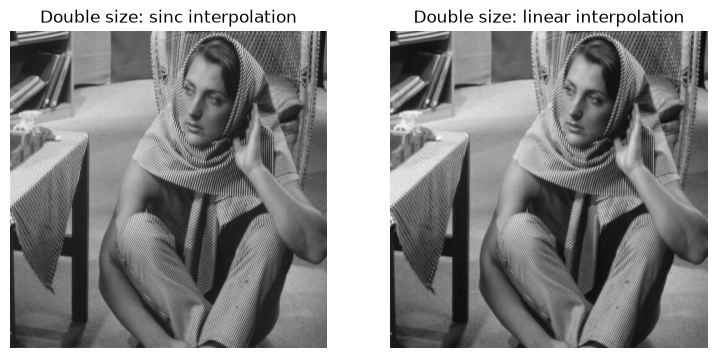

In [45]:
double_shape = (2*h, 2*w)
img_sinc = resize_fourier(img, double_shape)
img_linear = zoom(img, 2, order=1)

# Profilaktik Chek
print("max error vs original samples:", np.max(np.abs(img_sinc[::2, ::2] - img)))
print("natural vs centered, max abs diff:", np.max(np.abs(img_sinc - resize_fourier_centered(img, double_shape))))

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img_sinc, cmap="gray")
axes[0].set_title("Double size: sinc interpolation")
axes[1].imshow(img_linear, cmap="gray")
axes[1].set_title("Double size: linear interpolation")
for ax in axes:
    ax.axis("off")
plt.show()

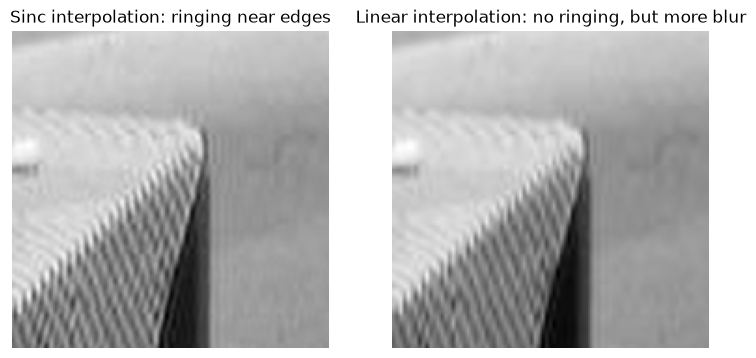

In [48]:
# crop to a small region to see the ringing
crop_half = np.s_[280:450, 150:320]

fig, axes = plt.subplots(1, 2, figsize=(9, 5))
axes[0].imshow(img_sinc[crop_half], cmap="gray")
axes[0].set_title("Sinc interpolation: ringing near edges")
axes[1].imshow(img_linear[crop_half], cmap="gray")
axes[1].set_title("Linear interpolation: no ringing, but more blur")
for ax in axes:
    ax.axis("off")
plt.show()


On the real photo, ringing and blur are hard to tell apart. Edges are not perfectly sharp and are already surrounded by texture. To make the difference unmistakable, we repeat the exact same two interpolations on a synthetic hard black/white step with no texture to hide behind.

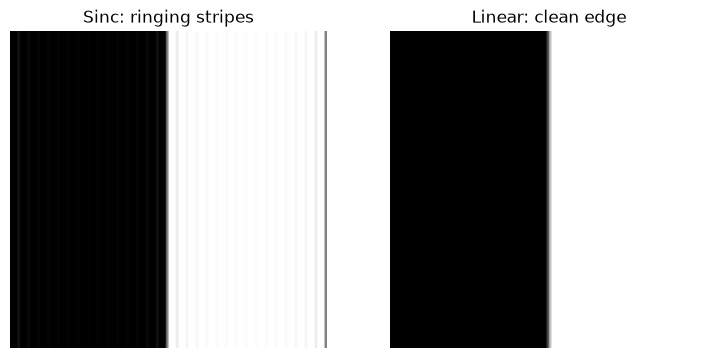

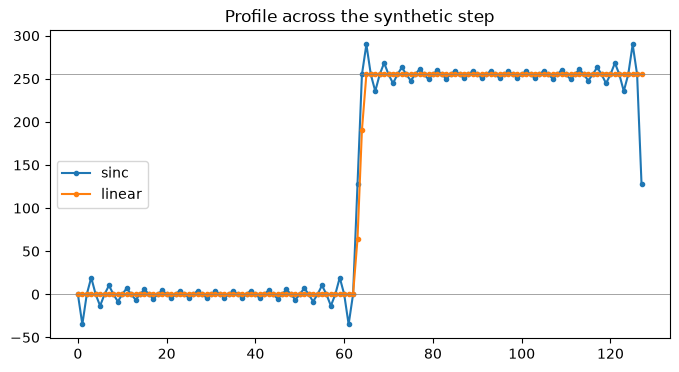

In [49]:
N = 64
step = np.zeros((N, N))
step[:, N // 2 :] = 255.0

step_sinc = resize_fourier(step, (2 * N, 2 * N))
step_linear = zoom(step, 2, order=1)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(step_sinc, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Sinc: ringing stripes")
axes[1].imshow(step_linear, cmap="gray", vmin=0, vmax=255)
axes[1].set_title("Linear: clean edge")
for ax in axes:
    ax.axis("off")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(step_sinc[N], ".-", label="sinc")
plt.plot(step_linear[N], ".-", label="linear")
plt.axhline(0, color="gray", lw=0.5)
plt.axhline(255, color="gray", lw=0.5)
plt.legend()
plt.title("Profile across the synthetic step")
plt.show()

I have read that this is called Gibbs phenomenon. Linear interpolation is a straight line between two samples, so by construction it can never overshoot, it just blurs the step over one pixel and stays flat everywhere else.

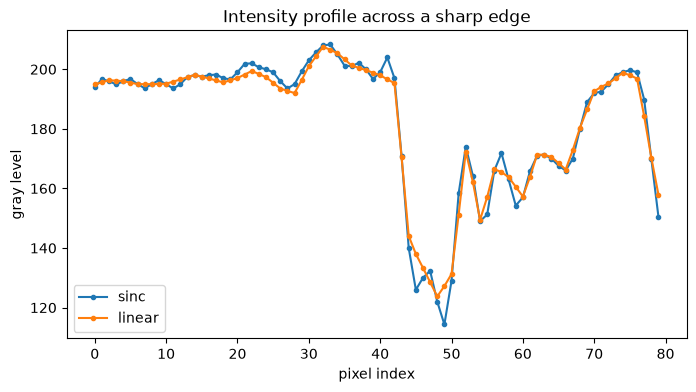

In [50]:
# 1D profile across a sharp edge (candle/vase on the table), doubled coordinates
row, cols = 2 * 163, slice(2 * 10, 2 * 50)

plt.figure(figsize=(8, 4))
plt.plot(img_sinc[row, cols], ".-", label="sinc")
plt.plot(img_linear[row, cols], ".-", label="linear")
plt.legend()
plt.title("Intensity profile across a sharp edge")
plt.xlabel("pixel index")
plt.ylabel("gray level")
plt.show()

Back on the real photo... The two curves overlap almost everywhere, but right at the sharp transition the sinc-interpolated curve overshoots and undershoots (around x=42-52) while the linear one just follows the edge smoothly. This is basically the same phenomenon as above, but much smaller.

## Conclusion

Both pairs of methods implement the same idea in the two domains, and the trade-off is always the same one predicted by the spectrum.
Sinc interpolation is the ideal band-limited reconstruction (exact on original samples) but we get "rings" at the sharp edges; linear interpolation is a cheap approximation that blurs edges instead of ringing.